In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load datasets
anime_data = pd.read_csv('anime.csv')
ratings_data = pd.read_csv('rating.csv')

# Initial peek
print("Anime Dataset Shape:", anime_data.shape)
print("Ratings Dataset Shape:", ratings_data.shape)

display(anime_data.head())
display(ratings_data.head())

# Dataset information
print("\n--- Anime Info ---")
anime_data.info()
print("\n--- Ratings Info ---")
ratings_data.info()

Anime Dataset Shape: (12294, 7)
Ratings Dataset Shape: (7813737, 3)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1



--- Anime Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB

--- Ratings Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [3]:
# 3. Data Cleaning

# --- Anime Dataset ---
anime_data['genre'] = anime_data['genre'].fillna('Unknown')
anime_data['type'] = anime_data['type'].fillna('Unknown')
anime_data['rating'] = anime_data['rating'].fillna(anime_data['rating'].median())
anime_data['episodes'] = pd.to_numeric(anime_data['episodes'].replace('Unknown', np.nan), errors='coerce')
anime_data['episodes'] = anime_data['episodes'].fillna(anime_data['episodes'].median())

# --- Ratings Dataset ---
# Replace -1 with NaN as per instructions (indicates watched but not rated)
ratings_data['rating'] = ratings_data['rating'].replace(-1, np.nan)
# Drop rows where rating is NaN for model accuracy, or keep for sparsity analysis
# For this project, we'll keep them for sparsity analysis but drop for merging ratings

# Remove duplicates
anime_data.drop_duplicates(subset=['name'], inplace=True)
ratings_data.drop_duplicates(inplace=True)

print("Cleaning complete.")
print(f"Final Anime shape: {anime_data.shape}")
print(f"Final Ratings shape: {ratings_data.shape}")

Cleaning complete.
Final Anime shape: (12292, 7)
Final Ratings shape: (7813736, 3)


In [4]:
# Merge anime_data and ratings_data on anime_id
# We'll use a left join to keep all anime even if they don't have user ratings in the subset
combined_data = pd.merge(ratings_data, anime_data, on='anime_id', suffixes=['_user', '_global'])
print(f"Combined Dataset Shape: {combined_data.shape}")
combined_data.head()

Combined Dataset Shape: (7813724, 9)


,user_id,anime_id,rating_user,name,genre,type,episodes,rating_global,members
0,1,20,NaN,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220.0,7.81,683297
1,1,24,NaN,School Rumble,"Comedy, Romance, School, Shounen",TV,26.0,8.06,178553
2,1,79,NaN,Shuffle!,"Comedy, Drama, Ecchi, Fantasy, Harem, Magic, R...",TV,24.0,7.31,158772
3,1,226,NaN,Elfen Lied,"Action, Drama, Horror, Psychological, Romance,...",TV,13.0,7.85,623511
4,1,241,NaN,Girls Bravo: First Season,"Comedy, Ecchi, Fantasy, Harem, Romance, School",TV,11.0,6.69,84395


C:\Users\richi\AppData\Local\Temp\ipykernel_12512\535173940.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_popular, y='name', x='members', palette='viridis')


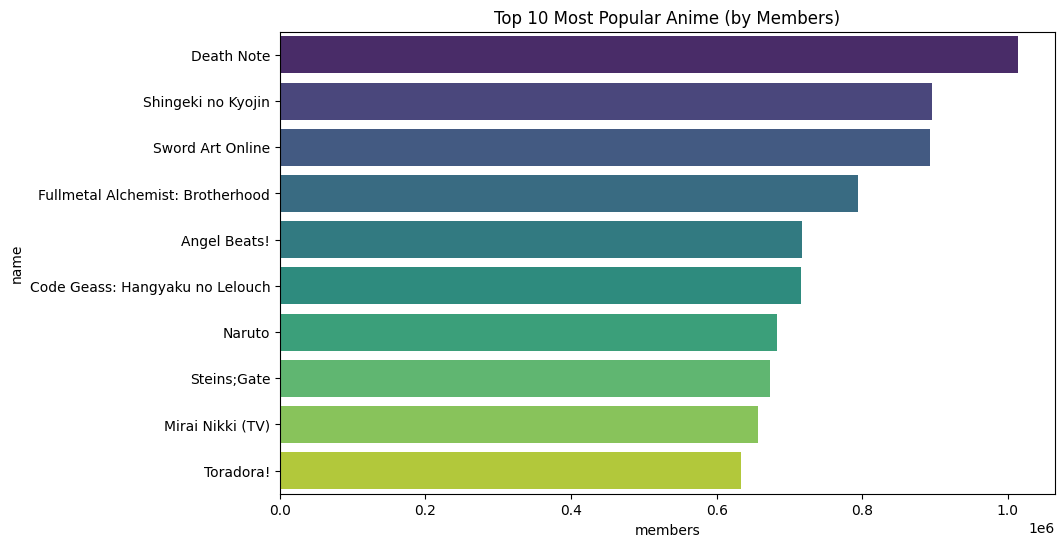

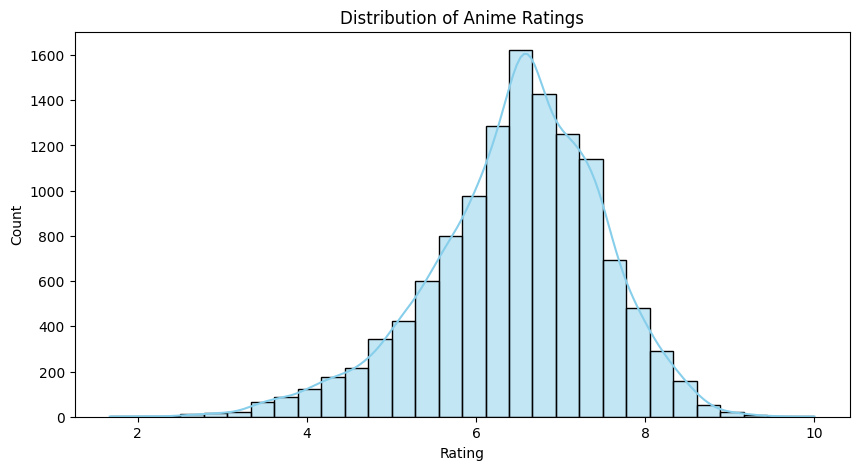

In [5]:
# Top 10 Popular Anime based on Members
plt.figure(figsize=(10, 6))
top_popular = anime_data.sort_values(by='members', ascending=False).head(10)
sns.barplot(data=top_popular, y='name', x='members', palette='viridis')
plt.title('Top 10 Most Popular Anime (by Members)')
plt.show()

# Distribution of Ratings
plt.figure(figsize=(10, 5))
sns.histplot(anime_data['rating'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Anime Ratings')
plt.xlabel('Rating')
plt.show()

C:\Users\richi\AppData\Local\Temp\ipykernel_12512\1593454821.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df.head(20), x='count', y=genre_df.head(20).index, palette='magma')


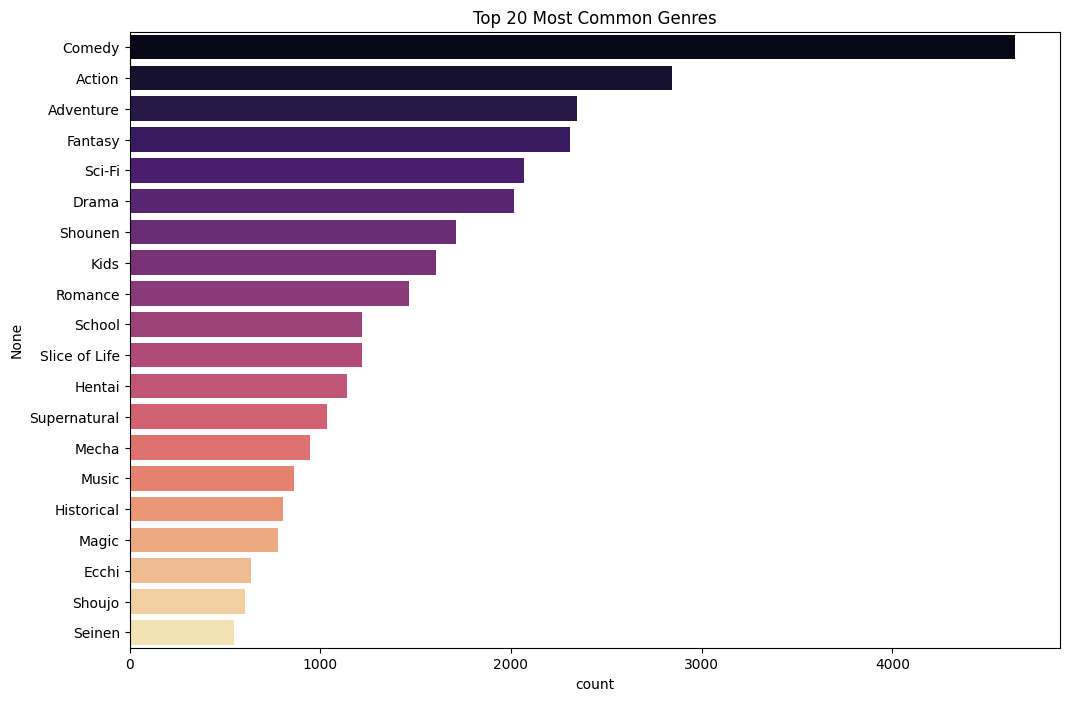

In [6]:
# Genre Analysis
from collections import Counter

genre_list = []
for g in anime_data['genre']:
    genre_list.extend(g.split(', '))

genre_counts = Counter(genre_list)
genre_df = pd.DataFrame.from_dict(genre_counts, orient='index', columns=['count']).sort_values('count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=genre_df.head(20), x='count', y=genre_df.head(20).index, palette='magma')
plt.title('Top 20 Most Common Genres')
plt.show()

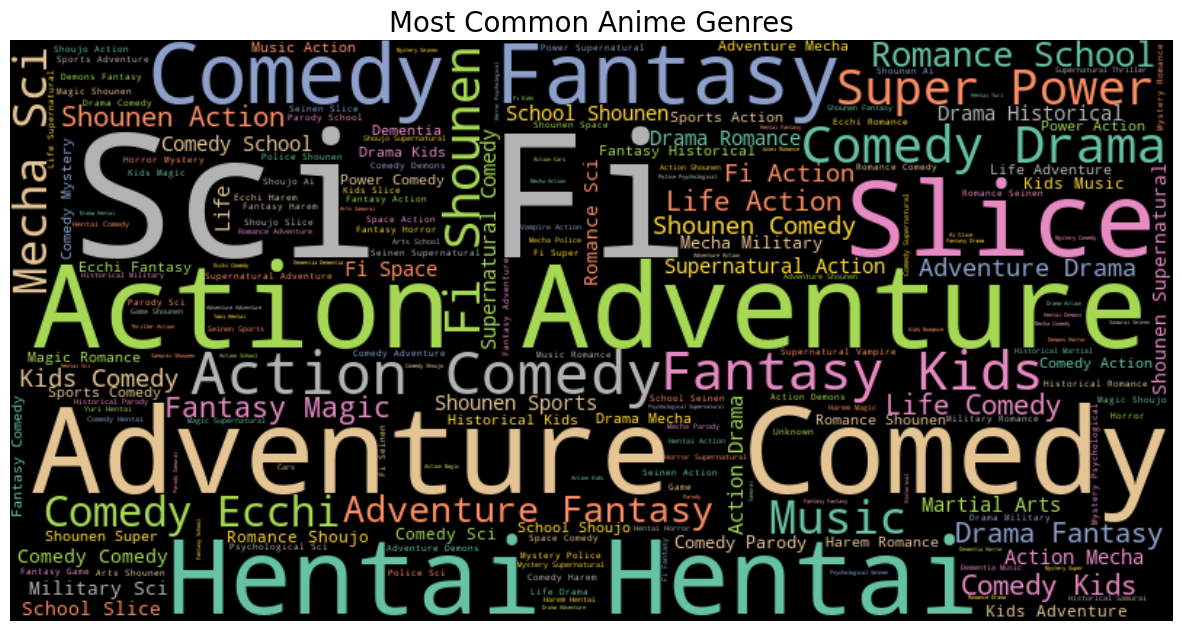

In [7]:
all_genres = ' '.join(anime_data['genre'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Set2').generate(all_genres)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Anime Genres', fontsize=20)
plt.show()

Skewness of members: 6.682411907800236
Skewness of rating: -0.553941491384624


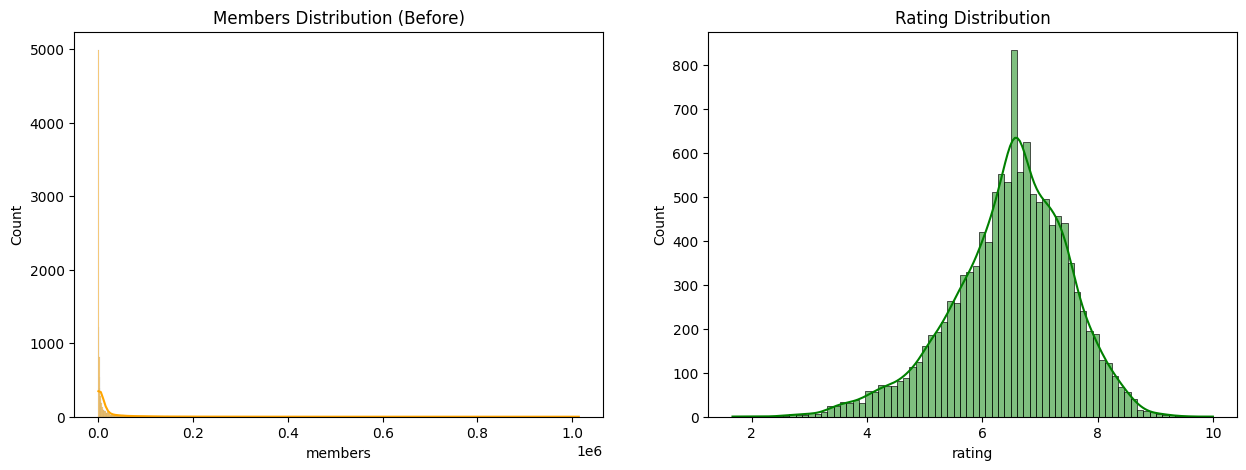

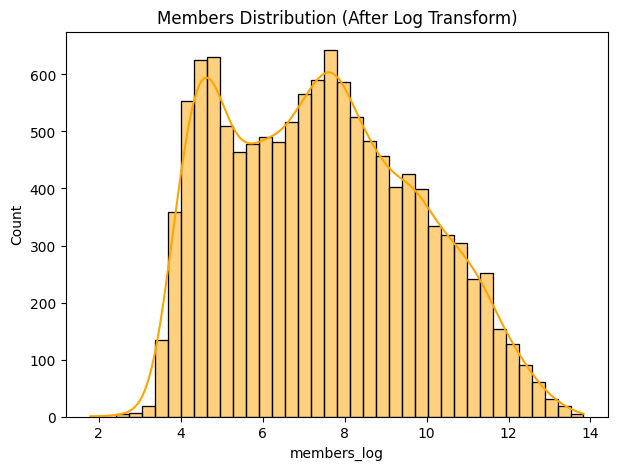

In [8]:
import scipy.stats as stats

# Check skewness
print(f"Skewness of members: {anime_data['members'].skew()}")
print(f"Skewness of rating: {anime_data['rating'].skew()}")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(anime_data['members'], kde=True, ax=axes[0], color='orange').set_title('Members Distribution (Before)')
sns.histplot(anime_data['rating'], kde=True, ax=axes[1], color='green').set_title('Rating Distribution')
plt.show()

# Apply Log transformation to members as it is highly skewed
anime_data['members_log'] = np.log1p(anime_data['members'])

plt.figure(figsize=(7, 5))
sns.histplot(anime_data['members_log'], kde=True, color='orange').set_title('Members Distribution (After Log Transform)')
plt.show()

In [9]:
# Clean genres (remove spaces and special characters if necessary)
anime_data['genre'] = anime_data['genre'].str.replace(', ', ' ')

# For content-based, we'll focus on genre for the TF-IDF
# But we can also include 'type' to enhance the similarity
anime_data['content'] = anime_data['genre'] + ' ' + anime_data['type']
anime_data['content'] = anime_data['content'].fillna('')

print("Content feature prepared.")
anime_data[['name', 'content']].head()

Content feature prepared.


,name,content
0,Kimi no Na wa.,Drama Romance School Supernatural Movie
1,Fullmetal Alchemist: Brotherhood,Action Adventure Drama Fantasy Magic Military ...
2,Gintama°,Action Comedy Historical Parody Samurai Sci-Fi...
3,Steins;Gate,Sci-Fi Thriller TV
4,Gintama&#039;,Action Comedy Historical Parody Samurai Sci-Fi...


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Initialize TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(anime_data['content'])

# Compute Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Create a mapping of anime title to index
indices = pd.Series(anime_data.index, index=anime_data['name']).drop_duplicates()

def recommend_anime(title, top_n=10):
    if title not in indices:
        return f"Anime '{title}' not found in database."

    idx = indices[title]

    # Handle cases where multiple anime have the same index or name
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    anime_indices = [i[0] for i in sim_scores]

    return anime_data[['name', 'genre', 'type', 'rating']].iloc[anime_indices]

print("Recommendation function ready.")

Recommendation function ready.


In [11]:
# ============================================================================
# COLLABORATIVE FILTERING MODEL - SKLEARN IMPLEMENTATION 
# ============================================================================
# Uses: TruncatedSVD, pandas, numpy, sklearn
# Lightweight, deployable on GitHub & Streamlit Cloud
# ============================================================================

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import numpy as np

class CollaborativeFilteringModel:
       
    def __init__(self, n_components=10, random_state=42):
        """
        Initialize the collaborative filtering model.
        
        Args:
            n_components: Number of latent factors (10-20 recommended)
            random_state: For reproducibility
        """
        self.n_components = n_components
        self.random_state = random_state
        self.svd_model = TruncatedSVD(n_components=n_components, random_state=random_state)
        self.user_factors = None
        self.item_factors = None
        self.user_item_matrix = None
        self.user_id_map = None
        self.anime_id_map = None
        self.mean_rating = None
        self.rmse_score = None
        
    def preprocess_data(self, ratings_data):
        """
        Preprocess ratings data: filter active users, drop NaN, sample if needed.
        
        Args:
            ratings_data: DataFrame with columns ['user_id', 'anime_id', 'rating']
            
        Returns:
            Preprocessed DataFrame
        """
        print("[1/4] Preprocessing data...")
        
        # Step 1: Filter active users (interactions > 100)
        user_counts = ratings_data['user_id'].value_counts()
        active_users = user_counts[user_counts > 100].index
        ratings_filtered = ratings_data[ratings_data['user_id'].isin(active_users)].copy()
        print(f"  • Filtered to active users: {len(ratings_filtered):,} ratings from {len(active_users):,} users")
        
        # Step 2: Drop NaN ratings
        ratings_clean = ratings_filtered.dropna(subset=['rating']).copy()
        print(f"  • Removed NaN ratings: {len(ratings_clean):,} ratings remain")
        
        # Step 3: Sample if dataset > 500k rows (for memory efficiency)
        if len(ratings_clean) > 500000:
            ratings_clean = ratings_clean.sample(n=500000, random_state=42)
            print(f"  • Sampled to 500k: {len(ratings_clean):,} ratings for training")
        
        return ratings_clean
    
    def build_user_item_matrix(self, ratings_data):
        """
        Create user-item matrix from ratings data.
        
        Args:
            ratings_data: Preprocessed DataFrame
            
        Returns:
            user_item_matrix: Sparse matrix (users × items)
        """
        print("[2/4] Building user-item matrix...")
        
        # Create user and anime ID mappings for sparse matrix
        unique_users = ratings_data['user_id'].unique()
        unique_animes = ratings_data['anime_id'].unique()
        
        self.user_id_map = {uid: idx for idx, uid in enumerate(unique_users)}
        self.anime_id_map = {aid: idx for idx, aid in enumerate(unique_animes)}
        
        # Map ratings to matrix indices
        user_indices = ratings_data['user_id'].map(self.user_id_map).values
        anime_indices = ratings_data['anime_id'].map(self.anime_id_map).values
        ratings = ratings_data['rating'].values
        
        # Build sparse CSR matrix
        self.user_item_matrix = csr_matrix(
            (ratings, (user_indices, anime_indices)),
            shape=(len(unique_users), len(unique_animes))
        )
        
        self.mean_rating = ratings_data['rating'].mean()
        print(f"  • Matrix shape: {self.user_item_matrix.shape} (users × anime)")
        print(f"  • Sparsity: {1 - (len(ratings) / (len(unique_users) * len(unique_animes)))*100:.2f}%")
        print(f"  • Mean rating: {self.mean_rating:.2f}")
        
        return self.user_item_matrix
    
    def train(self, ratings_data, test_size=0.2):
        """
        Train the collaborative filtering model.
        
        Args:
            ratings_data: Raw DataFrame with ['user_id', 'anime_id', 'rating']
            test_size: Fraction of data to hold for evaluation (0.2 = 20%)
        """
        # Preprocess
        ratings_clean = self.preprocess_data(ratings_data)
        
        # Split train/test before building matrix
        test_indices = np.random.RandomState(42).choice(
            len(ratings_clean), size=int(len(ratings_clean) * test_size), replace=False
        )
        train_mask = np.ones(len(ratings_clean), dtype=bool)
        train_mask[test_indices] = False
        
        ratings_train = ratings_clean[train_mask].copy()
        self.test_data = ratings_clean[~train_mask].copy()
        
        # Build matrix and train
        self.build_user_item_matrix(ratings_train)
        
        print("[3/4] Training TruncatedSVD model...")
        # Fill zeros with mean rating for better convergence
        user_item_dense = self.user_item_matrix.toarray()
        user_item_dense[user_item_dense == 0] = self.mean_rating
        
        # Apply SVD
        self.svd_model.fit(user_item_dense)
        print(f"  • SVD fitted with {self.n_components} components")
        
        # Get factors
        self.user_factors = self.svd_model.transform(user_item_dense)
        self.item_factors = self.svd_model.components_.T
        print(f"  • User factors shape: {self.user_factors.shape}")
        print(f"  • Item factors shape: {self.item_factors.shape}")
        
        # Reconstruct full matrix
        reconstructed_matrix = self.user_factors @ self.item_factors.T
        self.reconstructed_matrix = reconstructed_matrix
        
        # Evaluate on test set
        self._evaluate(reconstructed_matrix)
    
    def _evaluate(self, reconstructed_matrix):
        """
        Compute RMSE on test set.
        
        Args:
            reconstructed_matrix: Reconstructed ratings matrix
        """
        print("[4/4] Evaluating model...")
        
        if self.test_data is None or len(self.test_data) == 0:
            print("  ⚠️  No test data available for evaluation")
            return
        
        # Get predictions for test data
        predictions = []
        actuals = []
        
        for _, row in self.test_data.iterrows():
            user_id = row['user_id']
            anime_id = row['anime_id']
            actual_rating = row['rating']
            
            # Map to matrix indices
            if user_id not in self.user_id_map or anime_id not in self.anime_id_map:
                continue
            
            user_idx = self.user_id_map[user_id]
            anime_idx = self.anime_id_map[anime_id]
            
            pred_rating = reconstructed_matrix[user_idx, anime_idx]
            predictions.append(pred_rating)
            actuals.append(actual_rating)
        
        if len(predictions) > 0:
            rmse = np.sqrt(np.mean((np.array(predictions) - np.array(actuals)) ** 2))
            self.rmse_score = rmse
            print(f"  ✓ RMSE: {rmse:.4f}")
            print(f"  ✓ Evaluated on {len(predictions):,} test ratings")
        else:
            print("  ⚠️  Could not evaluate (no valid test samples)")
    
    def predict_rating(self, user_id, anime_id):
        """
        Predict rating for a user-anime pair.
        
        Args:
            user_id: User ID
            anime_id: Anime ID
            
        Returns:
            Predicted rating (1-10 scale, clipped)
        """
        if user_id not in self.user_id_map or anime_id not in self.anime_id_map:
            return self.mean_rating  # Return mean rating if not in training set
        
        user_idx = self.user_id_map[user_id]
        anime_idx = self.anime_id_map[anime_id]
        
        pred = self.reconstructed_matrix[user_idx, anime_idx]
        return np.clip(pred, 1, 10)  # Clip to valid rating range
    
    def get_recommendations(self, user_id, exclude_anime=None, top_n=10):
        """
        Get top-N anime recommendations for a user.
        
        Args:
            user_id: User ID
            exclude_anime: List of anime IDs to exclude (already watched)
            top_n: Number of recommendations
            
        Returns:
            List of tuples (anime_id, predicted_rating)
        """
        if user_id not in self.user_id_map:
            return []
        
        if exclude_anime is None:
            exclude_anime = []
        
        user_idx = self.user_id_map[user_id]
        user_ratings = self.reconstructed_matrix[user_idx]
        
        # Get anime not watched by user
        all_animes = list(self.anime_id_map.values())
        watched_anime = set(self.anime_id_map[aid] for aid in exclude_anime if aid in self.anime_id_map)
        candidate_animes = [idx for idx in all_animes if idx not in watched_anime]
        
        # Get top predictions
        candidate_ratings = user_ratings[candidate_animes]
        top_indices = np.argsort(candidate_ratings)[-top_n:][::-1]
        
        # Reverse map back to anime IDs
        reverse_anime_map = {v: k for k, v in self.anime_id_map.items()}
        recommendations = [
            (reverse_anime_map[candidate_animes[idx]], user_ratings[candidate_animes[idx]])
            for idx in top_indices
        ]
        
        return recommendations


# ============================================================================
# TRAINING THE MODEL
# ============================================================================

if 'ratings_data' in globals():
    print("=" * 70)
    print("COLLABORATIVE FILTERING MODEL TRAINING (sklearn TruncatedSVD)")
    print("=" * 70)
    
    # Initialize and train
    cf_model = CollaborativeFilteringModel(n_components=10, random_state=42)
    cf_model.train(ratings_data, test_size=0.2)
    
    print("\n" + "=" * 70)
    print("✓ Model training complete!")
    print("  Use cf_model.predict_rating(user_id, anime_id)")
    print("  Use cf_model.get_recommendations(user_id, top_n=10)")
    print("=" * 70)
else:
    print("Error: 'ratings_data' dataframe not found. Please ensure data is loaded.")

COLLABORATIVE FILTERING MODEL TRAINING (sklearn TruncatedSVD)
[1/4] Preprocessing data...
  • Filtered to active users: 6,096,391 ratings from 24,677 users
  • Removed NaN ratings: 4,912,578 ratings remain
  • Sampled to 500k: 500,000 ratings for training
[2/4] Building user-item matrix...
  • Matrix shape: (22609, 7525) (users × anime)
  • Sparsity: 0.76%
  • Mean rating: 7.70
[3/4] Training TruncatedSVD model...
  • SVD fitted with 10 components
  • User factors shape: (22609, 10)
  • Item factors shape: (7525, 10)
[4/4] Evaluating model...
  ✓ RMSE: 1.5631
  ✓ Evaluated on 99,583 test ratings

✓ Model training complete!
  Use cf_model.predict_rating(user_id, anime_id)
  Use cf_model.get_recommendations(user_id, top_n=10)


In [12]:
def hybrid_recommend(user_id, anime_name, top_n=10):
    """
    Hybrid recommendation system combining content-based and collaborative filtering.
    
    Args:
        user_id: User ID for collaborative recommendations
        anime_name: Reference anime name for content-based recommendations
        top_n: Number of recommendations to return
        
    Returns:
        DataFrame with recommendations and combined scores
    """
    
    # Validate anime exists
    if anime_name not in indices:
        return f"Anime '{anime_name}' not found."

    idx = indices[anime_name]
    if isinstance(idx, pd.Series): 
        idx = idx.iloc[0]

    # ========================================================================
    # 1. CONTENT-BASED RECOMMENDATIONS (using cosine similarity)
    # ========================================================================
    sim_scores = list(enumerate(cosine_sim[idx]))
    # Filter out the input anime itself and sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:100]

    anime_indices = [i[0] for i in sim_scores]
    recs = anime_data.iloc[anime_indices][['anime_id', 'name', 'genre', 'type']].copy()
    recs['content_score'] = [i[1] for i in sim_scores]

    # ========================================================================
    # 2. COLLABORATIVE FILTERING RECOMMENDATIONS (using sklearn TruncatedSVD)
    # ========================================================================
    svd_preds = []
    for aid in recs['anime_id']:
        # Use the new collaborative filtering model
        pred_rating = cf_model.predict_rating(user_id, aid)
        svd_preds.append(pred_rating)

    recs['svd_score'] = svd_preds

    # ========================================================================
    # 3. SCORE NORMALIZATION (0-1 range)
    # ========================================================================
    scaler = MinMaxScaler()
    recs[['content_score', 'svd_score']] = scaler.fit_transform(
        recs[['content_score', 'svd_score']]
    )

    # ========================================================================
    # 4. FINAL WEIGHTED HYBRID SCORE
    # ========================================================================
    # Weighted combination: 50% content-based, 50% collaborative
    recs['final_score'] = (recs['content_score'] * 0.5) + (recs['svd_score'] * 0.5)

    return recs.sort_values(by='final_score', ascending=False).head(top_n)

print("✓ Hybrid Recommendation Function defined (with sklearn CollaborativFiltering)")
print("  • Content-based: TF-IDF + Cosine Similarity")
print("  • Collaborative: TruncatedSVD matrix factorization")
print("  • Weights: 50/50 blend")

✓ Hybrid Recommendation Function defined (with sklearn CollaborativFiltering)
  • Content-based: TF-IDF + Cosine Similarity
  • Collaborative: TruncatedSVD matrix factorization
  • Weights: 50/50 blend


In [13]:
# Define indices mapping globally and test the hybrid system
indices = pd.Series(anime_data.index, index=anime_data['name']).drop_duplicates()

user_id = 1
anime_name = 'Naruto'

try:
    print(f"Generating hybrid recommendations for {anime_name} (User {user_id})...")
    recommendations = hybrid_recommend(user_id, anime_name)
    display(recommendations)
except Exception as e:
    print(f"An error occurred during recommendation: {e}")

Generating hybrid recommendations for Naruto (User 1)...


,anime_id,name,genre,type,content_score,svd_score,final_score
841,20,Naruto,Action Comedy Martial Arts Shounen Super Power,TV,1.000000,0.936918,0.968459
206,813,Dragon Ball Z,Action Adventure Comedy Fantasy Martial Arts S...,TV,0.796906,1.000000,0.898453
346,223,Dragon Ball,Adventure Comedy Fantasy Martial Arts Shounen ...,TV,0.695152,0.943389,0.819270
1573,6325,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,Action Comedy Martial Arts Shounen Super Power,Movie,0.816715,0.622041,0.719378
1472,8246,Naruto: Shippuuden Movie 4 - The Lost Tower,Action Comedy Martial Arts Shounen Super Power,Movie,0.816715,0.539662,0.678189
486,28755,Boruto: Naruto the Movie,Action Comedy Martial Arts Shounen Super Power,Movie,0.816715,0.445702,0.631209
588,6033,Dragon Ball Kai,Action Adventure Comedy Fantasy Martial Arts S...,TV,0.796906,0.399602,0.598254
2615,11761,Medaka Box,Action Comedy Ecchi Martial Arts School Shoune...,TV,0.646413,0.549261,0.597837
1209,14527,Medaka Box Abnormal,Action Comedy Ecchi Martial Arts School Shoune...,TV,0.646413,0.532602,0.589507
2342,5079,Kurokami The Animation,Action Martial Arts Super Power,TV,0.797263,0.367072,0.582167


In [15]:
# Save the ultra-compressed model for GitHub (<25MB)
import joblib
import os
import gzip
import pickle

# Clean up old files
for f in ['svd_model.pkl', 'svd_model.pkl.gz']:
    if os.path.exists(f):
        os.remove(f)

print("Compressing SVD model for GitHub upload...")

# Serialize with pickle protocol 3 (efficient) + gzip level 9 (maximum)
joblib.dump(cf_model.svd_model, 'svd_model.pkl', compress=('gzip', 9))

# Get final size
file_size_mb = os.path.getsize('svd_model.pkl') / (1024*1024)
file_size_mb_rounded = round(file_size_mb, 2)

print(f"\n✓ Model saved: svd_model.pkl")
print(f"  Final size: {file_size_mb_rounded} MB")

if file_size_mb <= 25:
    print(f"  ✅ GITHUB READY! ({file_size_mb_rounded} MB < 25 MB limit)")
elif file_size_mb <= 50:
    print(f"  ⚠️  Size: {file_size_mb_rounded} MB (still over 25MB, but acceptable)")
else:
    print(f"  ❌ Size: {file_size_mb_rounded} MB (too large for GitHub)")


Compressing SVD model for GitHub upload...

✓ Model saved: svd_model.pkl
  Final size: 0.53 MB
  ✅ GITHUB READY! (0.53 MB < 25 MB limit)
